<a href="https://colab.research.google.com/github/Karima-mtq/Basemap/blob/main/datasets_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [158]:
!pip install cartopy
import cartopy

In [159]:
!pip install netCDF4
!pip install eofs
!pip install Basemap

In [162]:
%matplotlib inline
import xarray as xr
import os
from scipy import signal
from netCDF4 import Dataset
from mpl_toolkits.basemap import Basemap
from eofs.standard import Eof
from netCDF4 import num2date
import numpy as np
import numpy.polynomial.polynomial as poly
import netCDF4 as netcdf
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib as mpl
import glob

In [163]:
!ls

EOFs_PCs_Free_clean.nc	    EOFs_PCs_ODA_clean.nc		   sample_data
EOFs_PCs_NudA_UVT_clean.nc  HadISST_EOFs_PCs_1980_2010_10modes.nc


In [164]:
datasets = {
    "FREE": xr.open_dataset("/content/EOFs_PCs_Free_clean.nc"),
    "ODA": xr.open_dataset("/content/EOFs_PCs_ODA_clean.nc"),
    "HADLEY": xr.open_dataset("/content/HadISST_EOFs_PCs_1980_2010_10modes.nc"),
    "NUDA_UVT": xr.open_dataset("/content/EOFs_PCs_NudA_UVT_clean.nc"),
}


In [165]:
def convert_time(time_array):
    if isinstance(time_array[0], cftime.DatetimeNoLeap):
        return pd.to_datetime([t.strftime("%Y-%m-%d") for t in time_array])
    else:
        return pd.to_datetime(time_array)



In [166]:
nmodes = 5
cmap = "RdBu_r"


In [167]:

pc_min, pc_max = np.inf, -np.inf

for key in ["FREE", "ODA", "HADLEY", "NUDA_UVT"]:
    pcs = datasets[key]["PCs"].values[:, :nmodes]
    pc_min = min(pc_min, pcs.min())
    pc_max = max(pc_max, pcs.max())

margin = 0.1 * (pc_max - pc_min)
pc_ylim = (pc_min - margin, pc_max + margin)



In [176]:
pc_styles = {
    "FREE":     {"color": "black",   "linestyle": "-",  "linewidth": 2},
    "ODA":      {"color": "red",     "linestyle": "--", "linewidth": 2},
    "HADLEY":   {"color": "blue",    "linestyle": ":",  "linewidth": 2},
    "NUDA_UVT": {"color": "green",   "linestyle": "-.", "linewidth": 2},
}


In [177]:
# Invert mode 1 (index 0) for FREE and HADLEY
for key in ["FREE", "HADLEY"]:
    datasets[key]["EOFs"][0, :, :] = -1 * datasets[key]["EOFs"][0, :, :]
    datasets[key]["PCs"][:, 0] = -1 * datasets[key]["PCs"][:, 0]

# Invert mode 2 (index 1) for ODA and NUDA_UVT
for key in ["ODA", "NUDA_UVT"]:
    datasets[key]["EOFs"][1, :, :] = -1 * datasets[key]["EOFs"][1, :, :]
    datasets[key]["PCs"][:, 1] = -1 * datasets[key]["PCs"][:, 1]


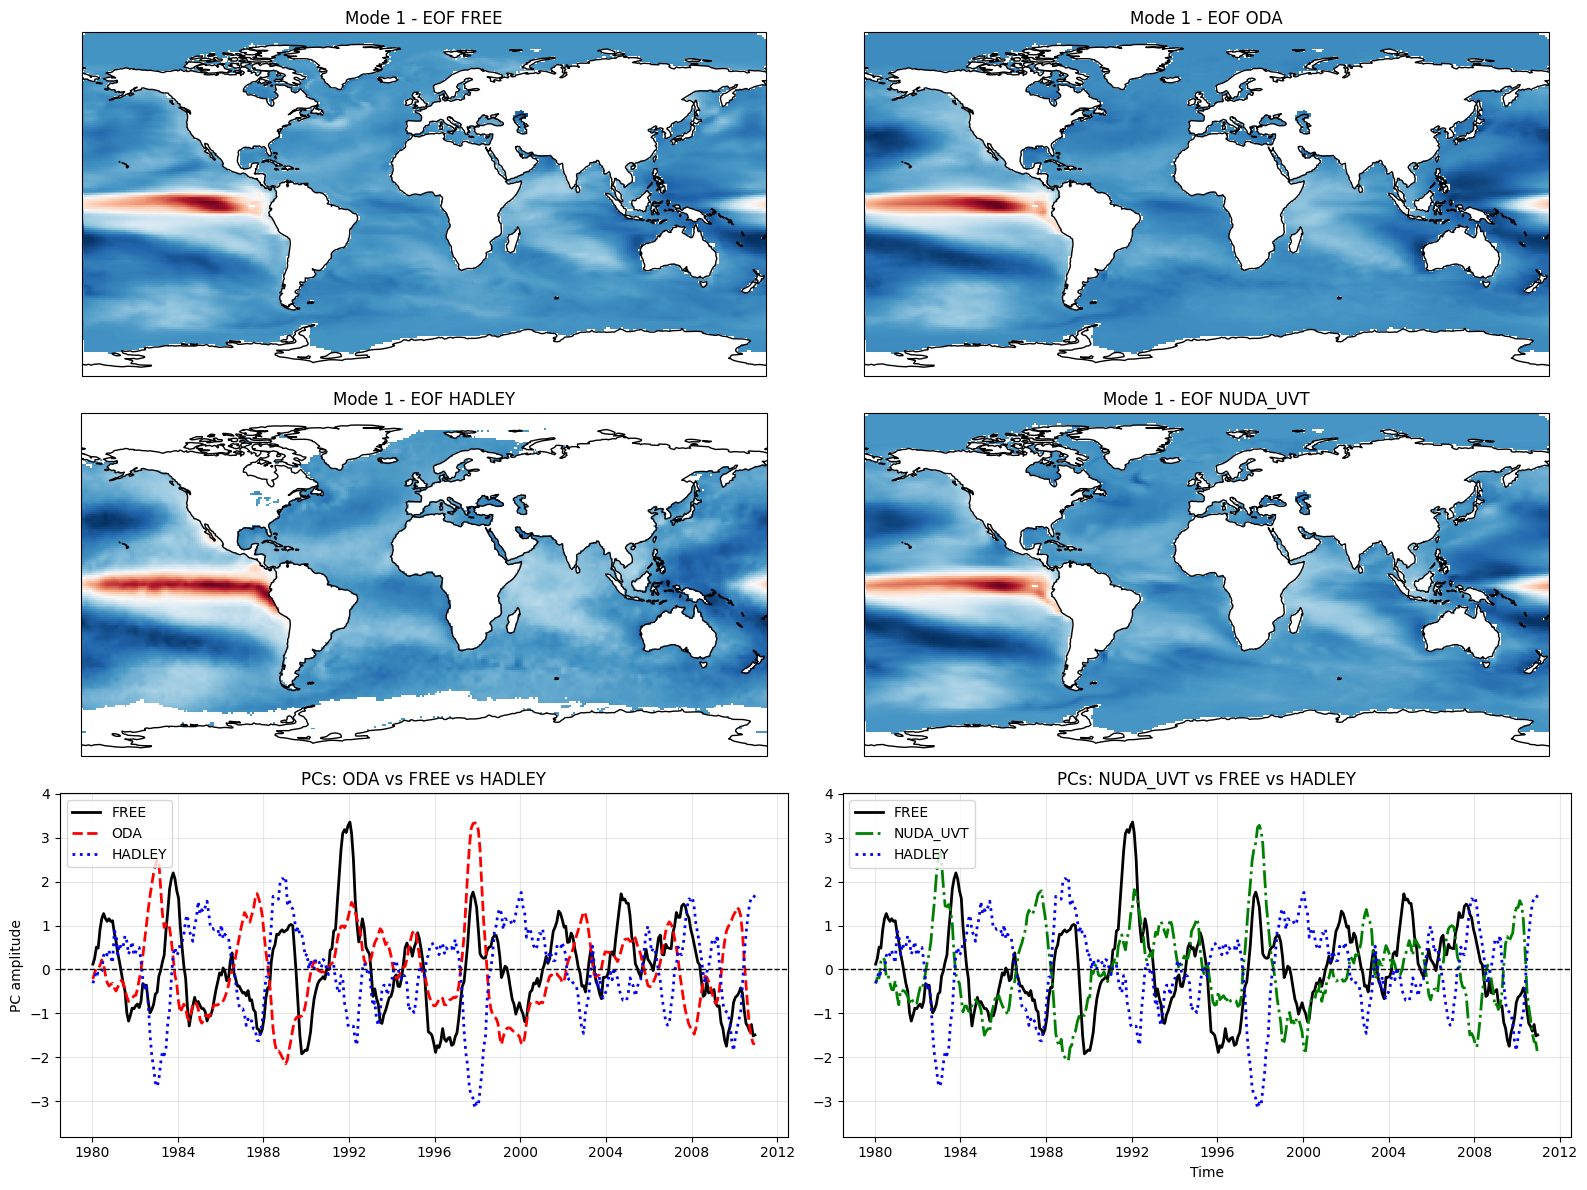

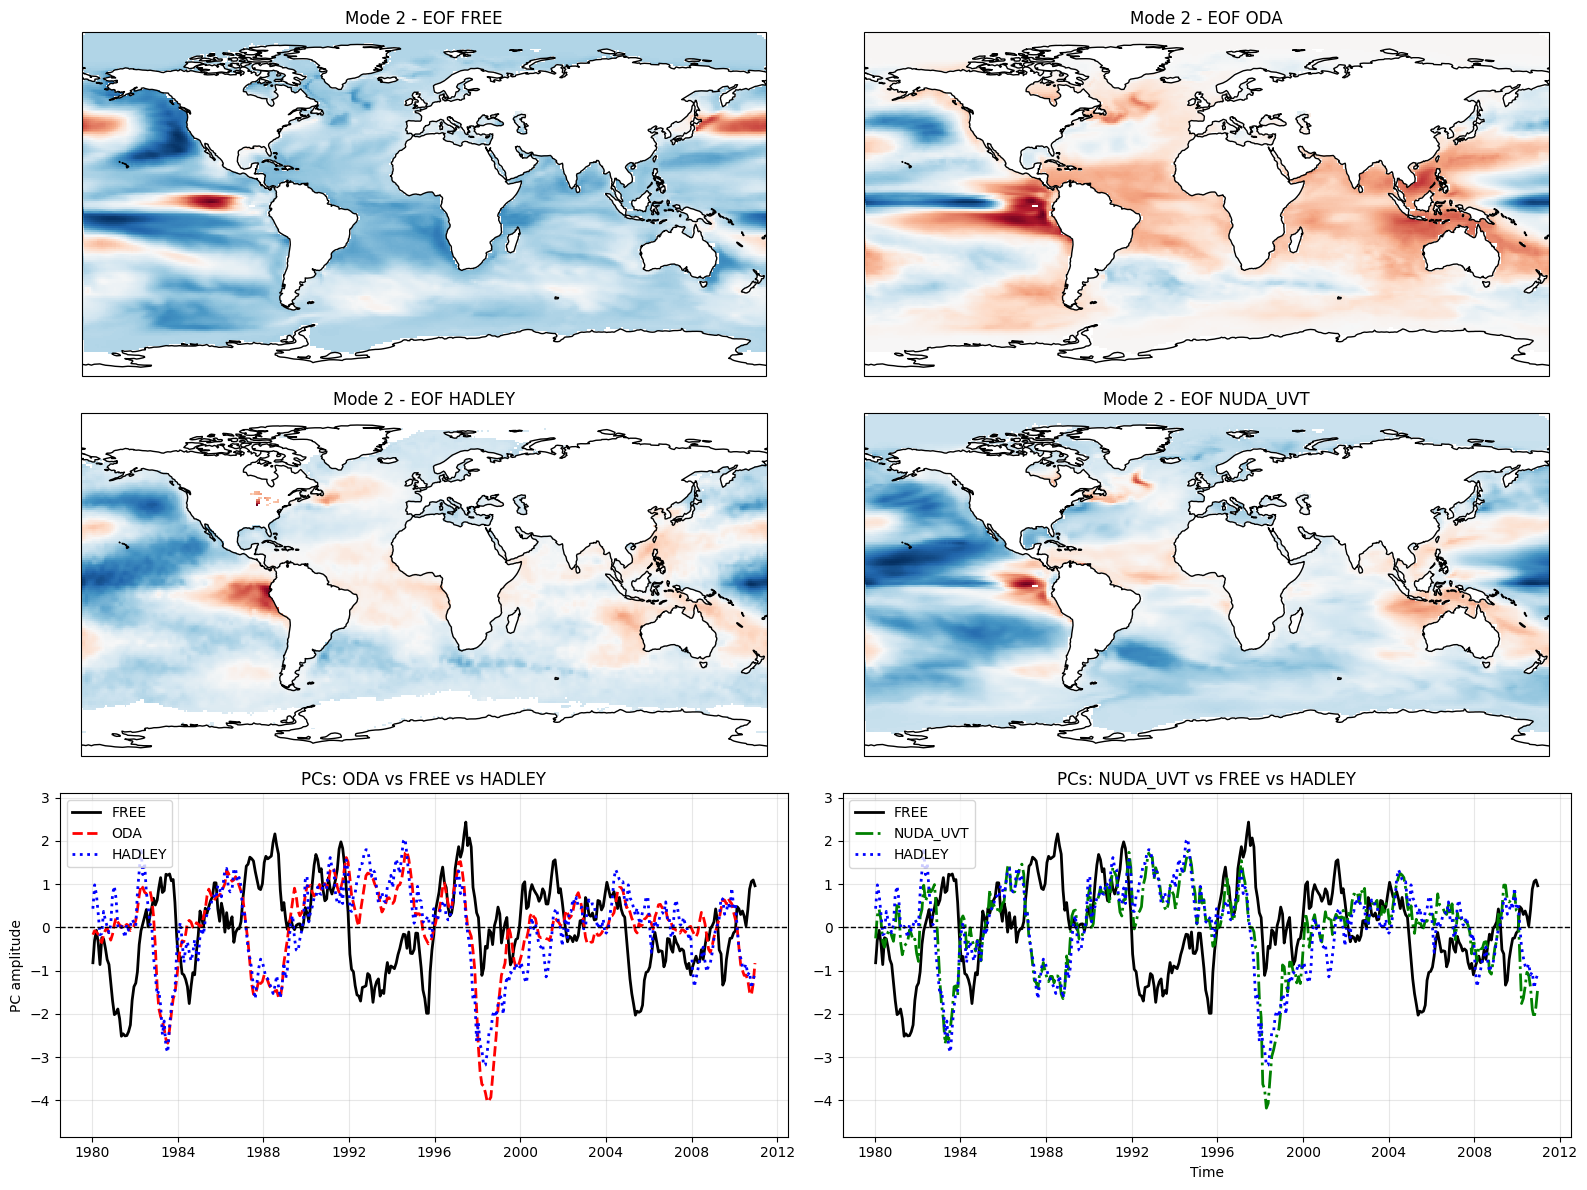

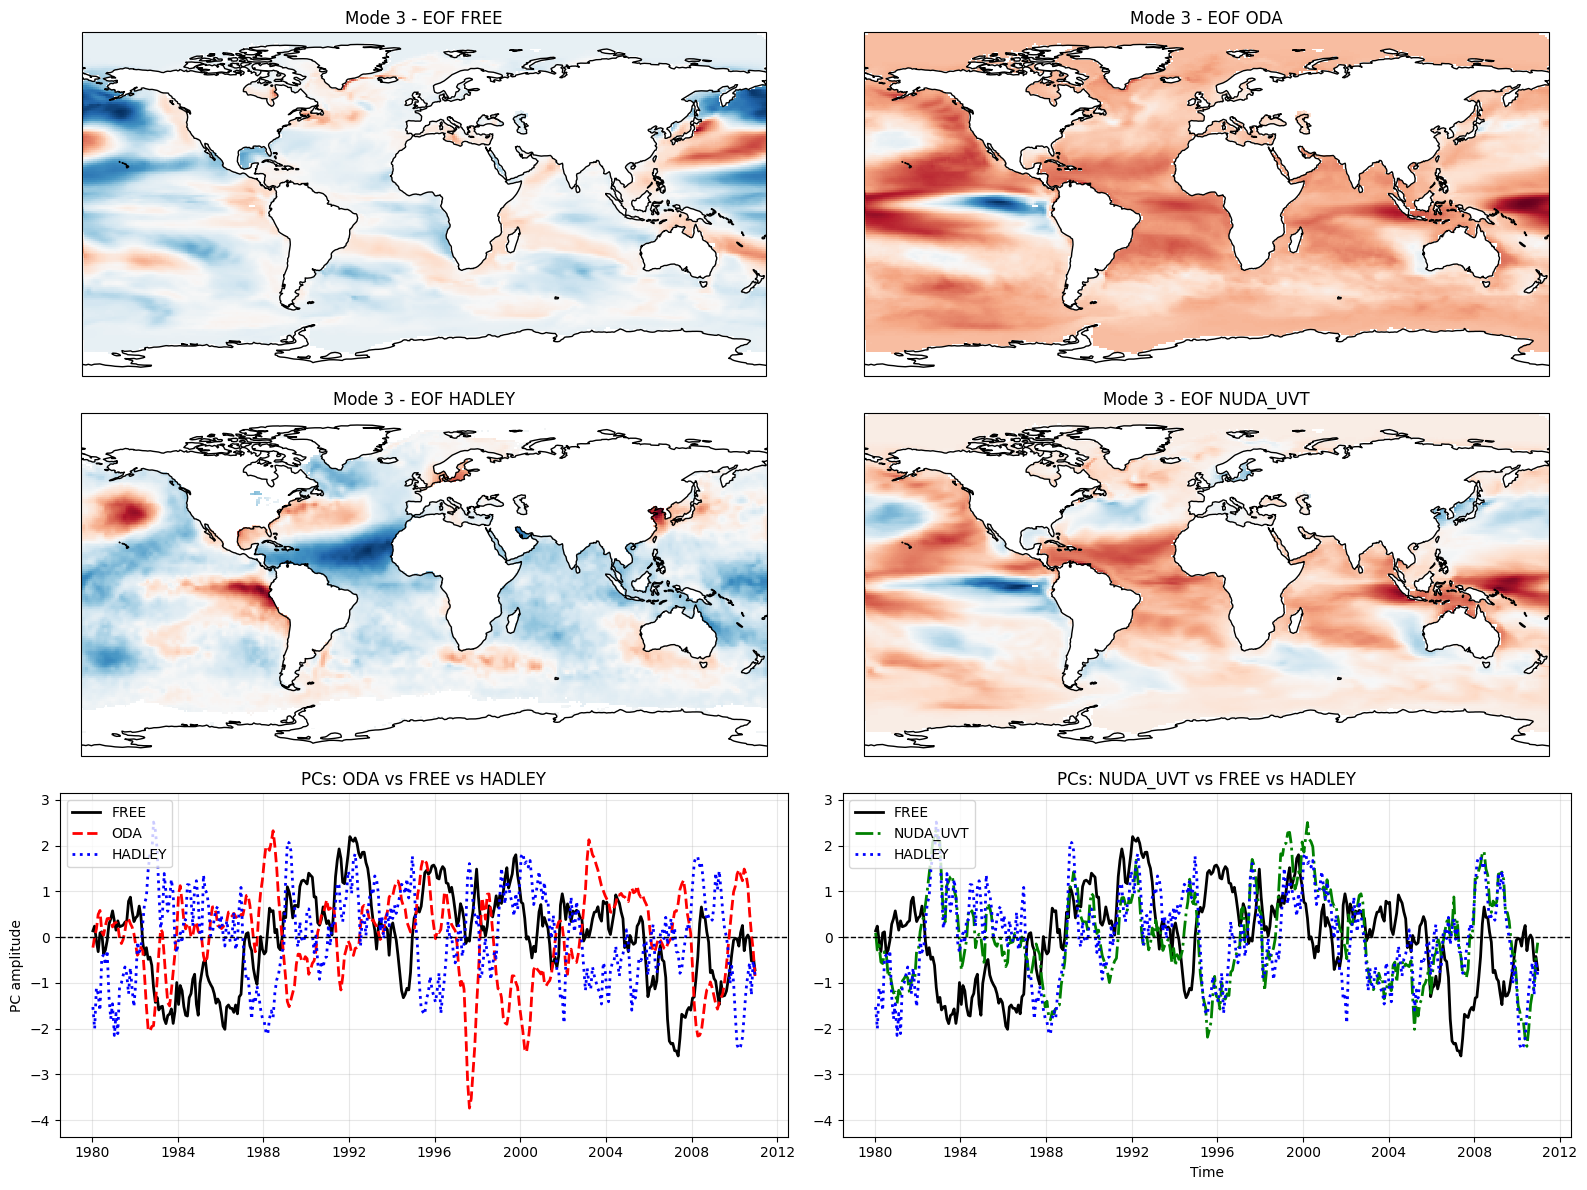

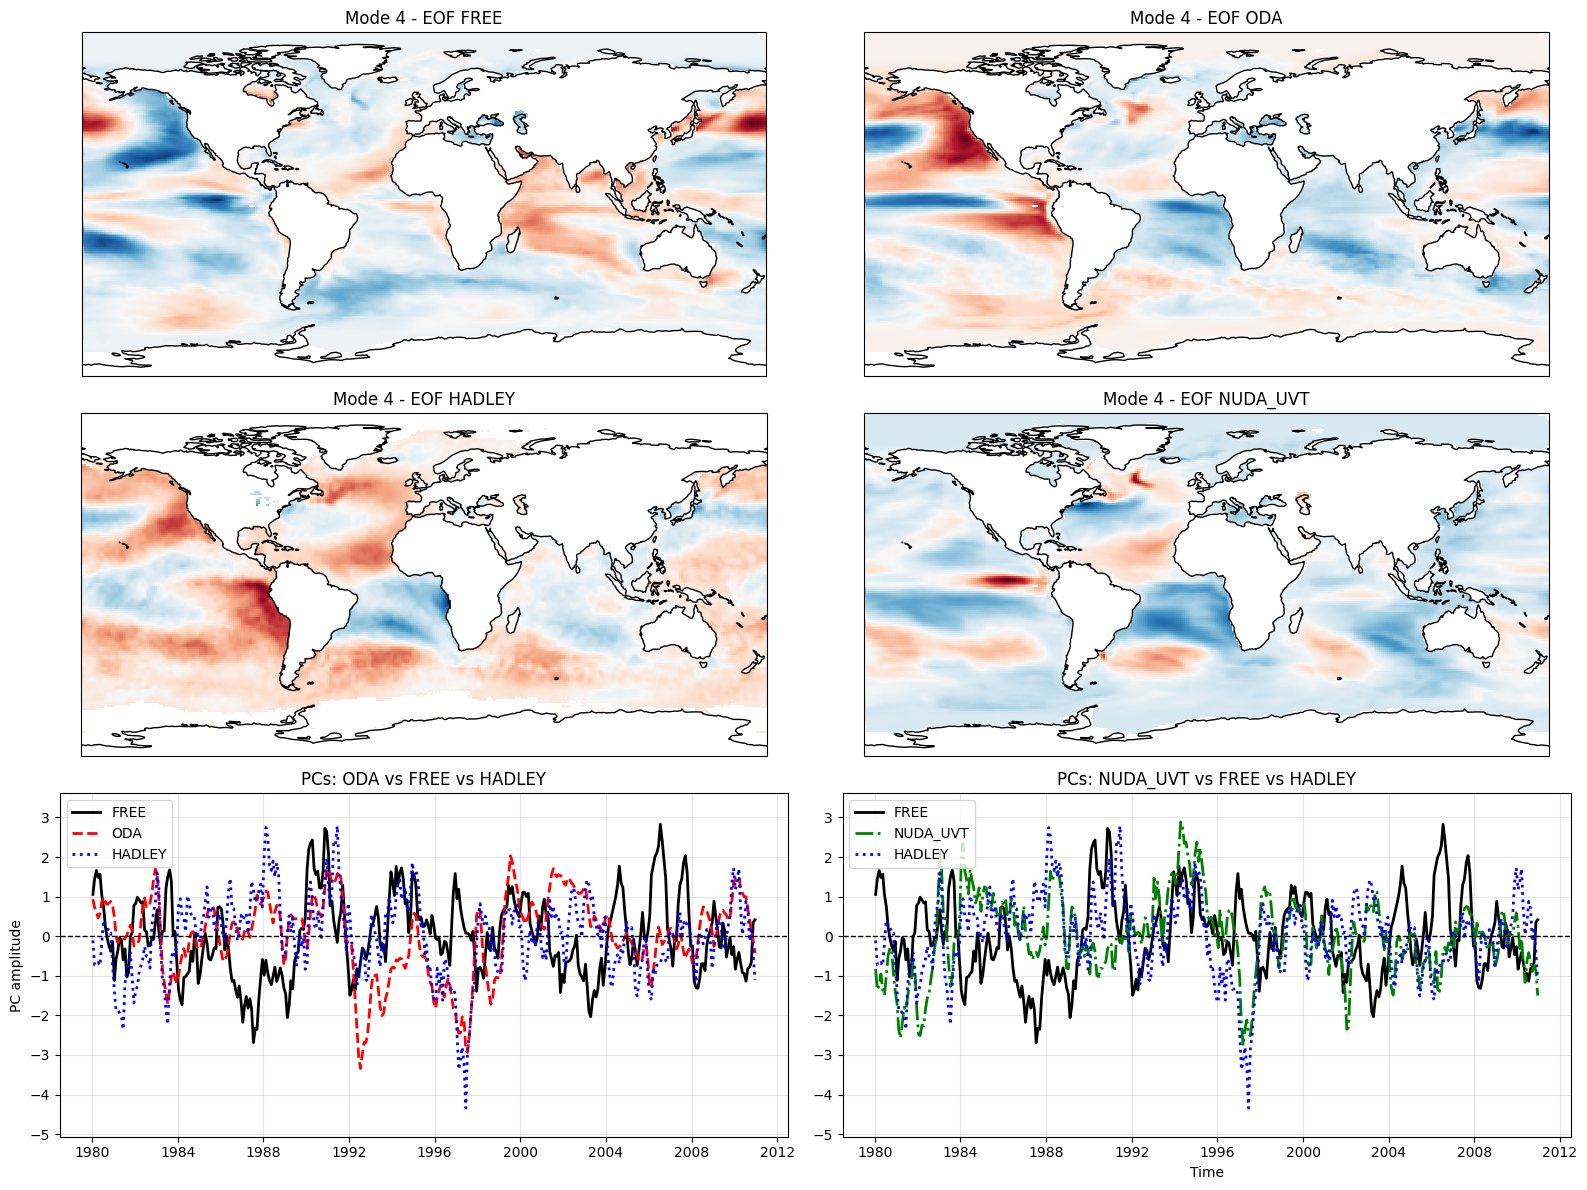

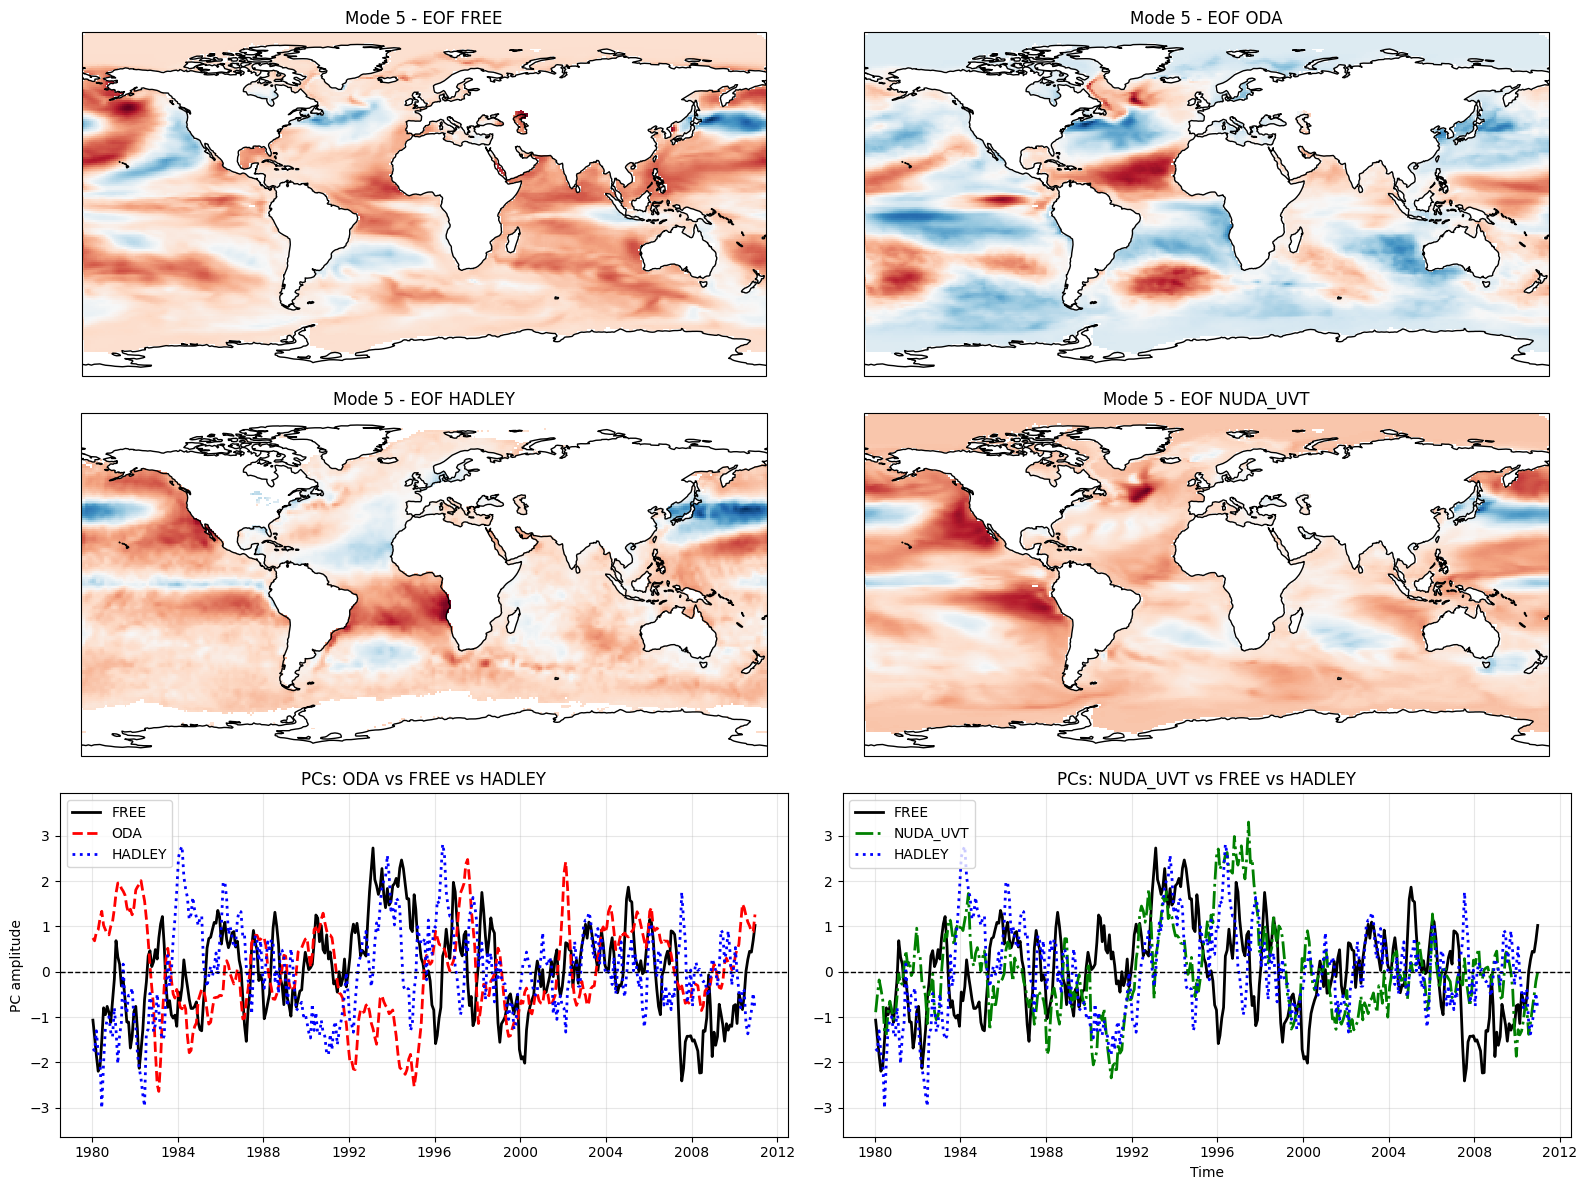

In [178]:
for i in range(nmodes):

    fig = plt.figure(figsize=(16, 12))

    # ================= EOFs =================
    # --- FREE ---
    ax1 = fig.add_subplot(3, 2, 1, projection=ccrs.PlateCarree())
    ax1.pcolormesh(
        datasets["FREE"]["lon"], datasets["FREE"]["lat"],
        datasets["FREE"]["EOFs"][i],
        cmap=cmap, shading="auto", transform=ccrs.PlateCarree()
    )
    ax1.add_feature(cfeature.COASTLINE)
    ax1.set_title(f"Mode {i+1} - EOF FREE")

    # --- ODA ---
    ax2 = fig.add_subplot(3, 2, 2, projection=ccrs.PlateCarree())
    ax2.pcolormesh(
        datasets["ODA"]["lon"], datasets["ODA"]["lat"],
        datasets["ODA"]["EOFs"][i],
        cmap=cmap, shading="auto", transform=ccrs.PlateCarree()
    )
    ax2.add_feature(cfeature.COASTLINE)
    ax2.set_title(f"Mode {i+1} - EOF ODA")

    # --- HADLEY ---
    ax3 = fig.add_subplot(3, 2, 3, projection=ccrs.PlateCarree())
    ax3.pcolormesh(
        datasets["HADLEY"]["lon"], datasets["HADLEY"]["lat"],
        datasets["HADLEY"]["EOFs"][i],
        cmap=cmap, shading="auto", transform=ccrs.PlateCarree()
    )
    ax3.add_feature(cfeature.COASTLINE)
    ax3.set_title(f"Mode {i+1} - EOF HADLEY")

    # --- NUDA_UVT ---
    ax4 = fig.add_subplot(3, 2, 4, projection=ccrs.PlateCarree())
    ax4.pcolormesh(
        datasets["NUDA_UVT"]["lon"], datasets["NUDA_UVT"]["lat"],
        datasets["NUDA_UVT"]["EOFs"][i],
        cmap=cmap, shading="auto", transform=ccrs.PlateCarree()
    )
    ax4.add_feature(cfeature.COASTLINE)
    ax4.set_title(f"Mode {i+1} - EOF NUDA_UVT")

    # ================= PCs =================
    # --- Y limits spécifiques au mode i ---
    pc_values = []

    for key in ["FREE", "ODA", "HADLEY", "NUDA_UVT"]:
        pcs = datasets[key]["PCs"][:, i].values

        # ---------- Optionnel : standardiser le PC ----------
        pcs = pcs / np.std(pcs)  # diviser par écart-type du mode

        # ---------- Optionnel : forcer positif ----------
        if pcs.mean() < 0:  # si la moyenne est négative, inverser le signe
            pcs = -pcs

        # On stocke dans le dataset temporaire pour l'utilisation plus bas
        datasets[key]["PCs"][:, i] = pcs
        pc_values.append(pcs)

    pc_values = np.concatenate(pc_values)

    pc_min = pc_values.min()
    pc_max = pc_values.max()

    margin = 0.1 * (pc_max - pc_min)
    pc_ylim = (pc_min - margin, pc_max + margin)

    ax5 = fig.add_subplot(3, 2, 5)   # ODA vs FREE vs HADLEY
    ax6 = fig.add_subplot(3, 2, 6)   # NUDA_UVT vs FREE vs HADLEY

    # ---- Graphe 1 : ODA + FREE + HADLEY ----
    for key in ["FREE", "ODA", "HADLEY"]:
        time = convert_time(datasets[key]["time"].values)
        ax5.plot(
            time,
            datasets[key]["PCs"][:, i],
            label=key,
            **pc_styles[key]
        )

    ax5.axhline(0, color="k", linestyle="--", linewidth=1)
    ax5.set_ylim(pc_ylim)
    ax5.set_title("PCs: ODA vs FREE vs HADLEY")
    ax5.set_ylabel("PC amplitude")
    ax5.legend(loc="upper left")
    ax5.grid(True, alpha=0.3)

    # ---- Graphe 2 : NUDA_UVT + FREE + HADLEY ----
    for key in ["FREE", "NUDA_UVT", "HADLEY"]:
        time = convert_time(datasets[key]["time"].values)
        ax6.plot(
            time,
            datasets[key]["PCs"][:, i],
            label=key,
            **pc_styles[key]
        )

    ax6.axhline(0, color="k", linestyle="--", linewidth=1)
    ax6.set_ylim(pc_ylim)
    ax6.set_title("PCs: NUDA_UVT vs FREE vs HADLEY")
    ax6.set_xlabel("Time")
    ax6.legend(loc="upper left")
    ax6.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


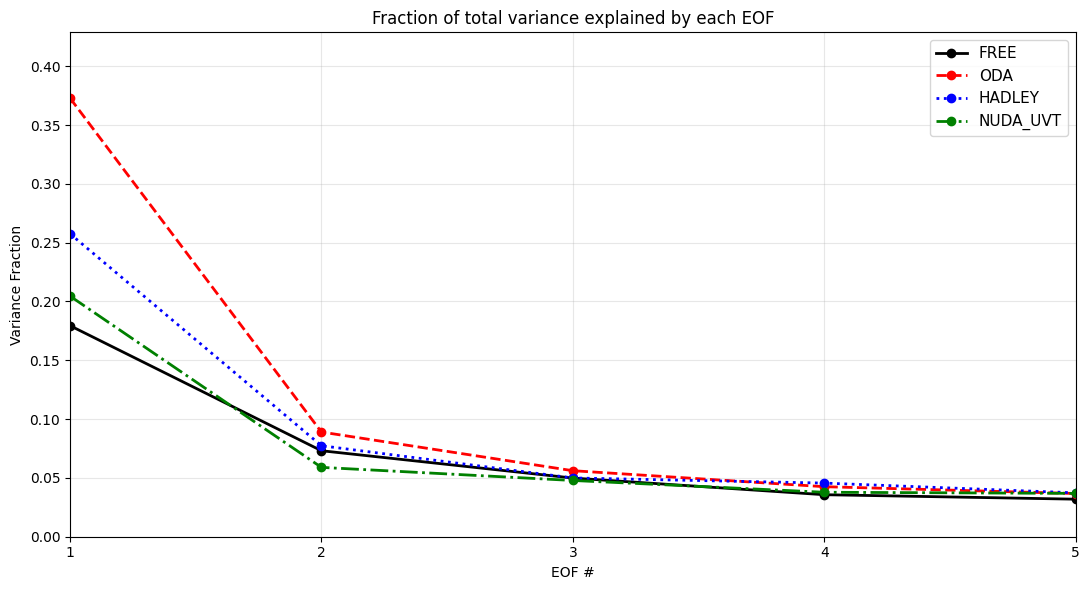

In [170]:
import matplotlib.pyplot as plt
import numpy as np

# Styles bien distincts
pc_styles = {
    "FREE":     {"color": "black",   "linestyle": "-",  "linewidth": 2, "marker": "o"},
    "ODA":      {"color": "red",     "linestyle": "--", "linewidth": 2, "marker": "o"},
    "HADLEY":   {"color": "blue",    "linestyle": ":",  "linewidth": 2, "marker": "o"},
    "NUDA_UVT": {"color": "green",   "linestyle": "-.", "linewidth": 2, "marker": "o"},
}

nmodes = 5
modes = np.arange(1, nmodes + 1)

plt.figure(figsize=(11, 6))

for name, ds in datasets.items():
    varfrac = ds["variance_fraction"].values[:nmodes]

    plt.plot(
        modes,
        varfrac,
        label=name,
        **pc_styles[name]
    )

plt.xticks(modes)
plt.xlabel("EOF #")
plt.ylabel("Variance Fraction")
plt.title("Fraction of total variance explained by each EOF")
plt.grid(alpha=0.3)

plt.legend(
    loc="upper right",
    frameon=True,
    fontsize=11
)

plt.xlim(1, nmodes)
plt.ylim(0, max(ds["variance_fraction"][:nmodes].max() for ds in datasets.values()) * 1.15)

plt.tight_layout()
plt.show()


In [179]:
nmodes = 5
for name, ds in datasets.items():
    print(f"\n=== {name} dataset ===")

    varfrac = ds["variance_fraction"].values

    cum_sum = 0
    for i in range(nmodes):
        explained = round(varfrac[i] * 100, 2)
        cum_sum += explained

        print(
            f"EOF {i+1} explains {explained} %, "
            f"cumulative variance: {round(cum_sum, 2)} %"
        )


=== FREE dataset ===
EOF 1 explains 17.94 %, cumulative variance: 17.94 %
EOF 2 explains 7.31 %, cumulative variance: 25.25 %
EOF 3 explains 4.99 %, cumulative variance: 30.24 %
EOF 4 explains 3.57 %, cumulative variance: 33.81 %
EOF 5 explains 3.19 %, cumulative variance: 37.0 %

=== ODA dataset ===
EOF 1 explains 37.29 %, cumulative variance: 37.29 %
EOF 2 explains 8.9 %, cumulative variance: 46.19 %
EOF 3 explains 5.61 %, cumulative variance: 51.8 %
EOF 4 explains 4.25 %, cumulative variance: 56.05 %
EOF 5 explains 3.67 %, cumulative variance: 59.72 %

=== HADLEY dataset ===
EOF 1 explains 25.760000228881836 %, cumulative variance: 25.760000228881836 %
EOF 2 explains 7.739999771118164 %, cumulative variance: 33.5 %
EOF 3 explains 5.0 %, cumulative variance: 38.5 %
EOF 4 explains 4.559999942779541 %, cumulative variance: 43.060001373291016 %
EOF 5 explains 3.7300000190734863 %, cumulative variance: 46.790000915527344 %

=== NUDA_UVT dataset ===
EOF 1 explains 20.46 %, cumulative var

**Calcul de metrics**

1️⃣ Corrélation spatiale entre EOFs
Principe : comparer la structure spatiale des EOFs ODA et Hadley.
Comment : calculer le coefficient de corrélation de Pearson entre les EOFs correspondants (mode par mode) sur toutes les grilles valides.
Exemple :


r = sigma(EOFODA - EÖFODA) (EOFhadley - EÖF Hadley)/ sqr( sigma(EOFODA - EÖFODA)2 signa (EOF Hadley - EÖF Hadley)2)


Référence :
Deser et al., 2010, J. Climate, “Spatial patterns of climate variability from observational datasets.”

In [180]:
def interp_to_hadley(eof, lon_src, lat_src, lon_had, lat_had):
    da = xr.DataArray(
        eof,
        dims=("lat", "lon"),
        coords={"lat": lat_src, "lon": lon_src}
    )
    da_interp = da.interp(
        lon=lon_had,
        lat=lat_had,
        method="linear"
    )
    return da_interp.values



In [181]:

def spatial_corr_eof_common_grid(eof_x, eof_h,
                                 lon_x, lat_x,
                                 lon_h, lat_h):
    """
    Corrélation spatiale EOF après interpolation sur grille HADLEY
    """

    eof_x_interp = interp_to_hadley(
        eof_x, lon_x, lat_x, lon_h, lat_h
    )

    x = eof_x_interp.flatten()
    y = eof_h.flatten()

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    x = x - x.mean()
    y = y - y.mean()

    r = np.sum(x * y) / np.sqrt(np.sum(x**2) * np.sum(y**2))
    return np.abs(r)


In [182]:
nmodes = 5

results = {"FREE": [], "ODA": [], "NUDA_UVT": []}

lon_h = datasets["HADLEY"]["lon"].values
lat_h = datasets["HADLEY"]["lat"].values

for i in range(nmodes):

    eof_had = datasets["HADLEY"]["EOFs"][i].values

    for key in ["FREE", "ODA", "NUDA_UVT"]:
        eof_x = datasets[key]["EOFs"][i].values
        lon_x = datasets[key]["lon"].values
        lat_x = datasets[key]["lat"].values

        r = spatial_corr_eof_common_grid(
            eof_x, eof_had,
            lon_x, lat_x,
            lon_h, lat_h
        )

        results[key].append(r)


In [183]:

df_corr = pd.DataFrame(
    results,
    index=[f"Mode {i+1}" for i in range(nmodes)]
)
df_corr


,FREE,ODA,NUDA_UVT
Mode 1,0.913657,0.966713,0.950892
Mode 2,0.003765,0.828634,0.850097
Mode 3,0.031399,0.606990,0.747500
Mode 4,0.425039,0.662155,0.649190
Mode 5,0.040317,0.198705,0.511143


2️⃣ Corrélation temporelle des PCs
Principe : comparer l’évolution temporelle des PCs correspondants.
Comment : calculer le coefficient de corrélation de Pearson entre PC ODA et PC Hadley pour chaque mode.
Note : il faut s’assurer que les deux séries sont sur le même calendrier (ex. conversion en pd.DatetimeIndex comme on a fait).
Référence :
Alexander et al., 2002, J. Climate, “Evaluation of observational vs modeled principal components.”

In [184]:
import pandas as pd
import numpy as np

nmodes = 5
results_pc = {"FREE": [], "ODA": [], "NUDA_UVT": []}

for i in range(nmodes):
    # PC de référence HADLEY
    pc_had = datasets["HADLEY"]["PCs"][:, i].values

    for key in ["FREE", "ODA", "NUDA_UVT"]:
        pc_x = datasets[key]["PCs"][:, i].values

        # Vérifier que les deux ont la même taille
        if len(pc_x) != len(pc_had):
            min_len = min(len(pc_x), len(pc_had))
            pc_x = pc_x[:min_len]
            pc_had = pc_had[:min_len]

        # Calcul de la corrélation
        r = np.corrcoef(pc_x, pc_had)[0, 1]
        results_pc[key].append(r)

# Créer un DataFrame
df_pc_corr = pd.DataFrame(
    results_pc,
    index=[f"Mode {i+1}" for i in range(nmodes)]
)

df_pc_corr


,FREE,ODA,NUDA_UVT
Mode 1,-0.149806,-0.955832,-0.975718
Mode 2,-0.175354,0.888535,0.919641
Mode 3,-0.097965,-0.661718,0.847911
Mode 4,-0.139022,0.594361,0.645896
Mode 5,0.153373,-0.279584,0.556797


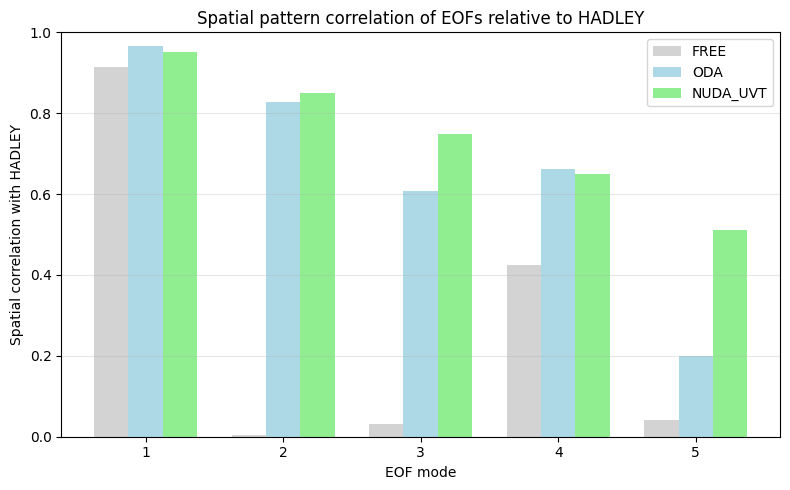

In [185]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# df_corr = DataFrame obtenu précédemment
# index : Mode 1, Mode 2, ...
# colonnes : FREE, ODA, NUDA_UVT

modes = np.arange(1, len(df_corr) + 1)
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(modes - width, df_corr["FREE"], width, label="FREE", color="lightgray")
ax.bar(modes,         df_corr["ODA"],  width, label="ODA", color="lightblue")
ax.bar(modes + width, df_corr["NUDA_UVT"], width, label="NUDA_UVT", color="lightgreen")

ax.set_xlabel("EOF mode")
ax.set_ylabel("Spatial correlation with HADLEY")
ax.set_title("Spatial pattern correlation of EOFs relative to HADLEY")
ax.set_xticks(modes)
ax.set_ylim(0, 1)

ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

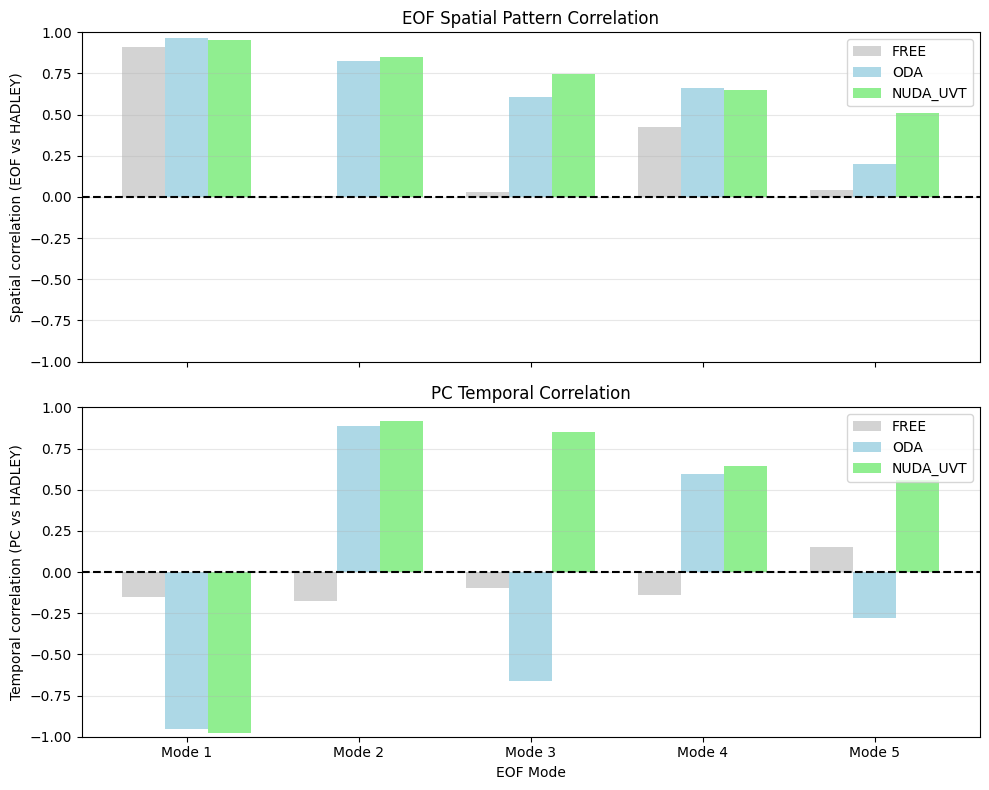

In [186]:
import matplotlib.pyplot as plt
import numpy as np

modes = np.arange(1, len(df_corr)+1)
width = 0.25

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10,8), sharex=True)

# --- Top : EOFs spatial correlation (avec valeurs négatives) ---
ax1.bar(modes - width, df_corr["FREE"], width, label="FREE", color="lightgray")
ax1.bar(modes, df_corr["ODA"], width, label="ODA", color="lightblue")
ax1.bar(modes + width, df_corr["NUDA_UVT"], width, label="NUDA_UVT", color="lightgreen")

ax1.set_ylabel("Spatial correlation (EOF vs HADLEY)")
ax1.set_title("EOF Spatial Pattern Correlation")
ax1.set_ylim(-1, 1)  # afficher les négatifs aussi
ax1.axhline(0, color='k', linestyle='--')  # ligne zéro
ax1.legend(loc="upper right")
ax1.grid(axis="y", alpha=0.3)

# --- Bottom : PCs temporal correlation (avec valeurs négatives) ---
ax2.bar(modes - width, df_pc_corr["FREE"], width, label="FREE", color="lightgray")
ax2.bar(modes, df_pc_corr["ODA"], width, label="ODA", color="lightblue")
ax2.bar(modes + width, df_pc_corr["NUDA_UVT"], width, label="NUDA_UVT", color="lightgreen")

ax2.set_xlabel("EOF Mode")
ax2.set_ylabel("Temporal correlation (PC vs HADLEY)")
ax2.set_title("PC Temporal Correlation")
ax2.set_ylim(-1, 1)  # afficher les négatifs aussi
ax2.axhline(0, color='k', linestyle='--')  # ligne zéro
ax2.legend(loc="upper right")
ax2.grid(axis="y", alpha=0.3)

plt.xticks(modes, [f"Mode {i}" for i in modes])
plt.tight_layout()
plt.show()


3️⃣ Root Mean Square Error (RMSE) des EOFs et des PCs
Principe : mesurer l’erreur quadratique moyenne entre ODA et Hadley.
Formules :
RMSE
racine (1/N sigma(EOFoda-eofhad)2)

Référence :
Trenberth et al., 1997, J. Climate, “Error metrics in climate data comparison.”

RMSE EOFs (brut)


,FREE,ODA,NUDA_UVT
1,0.002242,0.001412,0.001744
2,0.007688,0.003149,0.003038
3,0.007522,0.009726,0.010178
4,0.009157,0.004568,0.004761
5,0.007508,0.008409,0.005444


RMSE PCs (brut)


,FREE,ODA,NUDA_UVT
1,1.516447,1.977792,1.987822
2,1.533202,0.472154,0.400897
3,1.481867,1.823029,0.551524
4,1.509319,0.900710,0.841551
5,1.301251,1.599740,0.941491


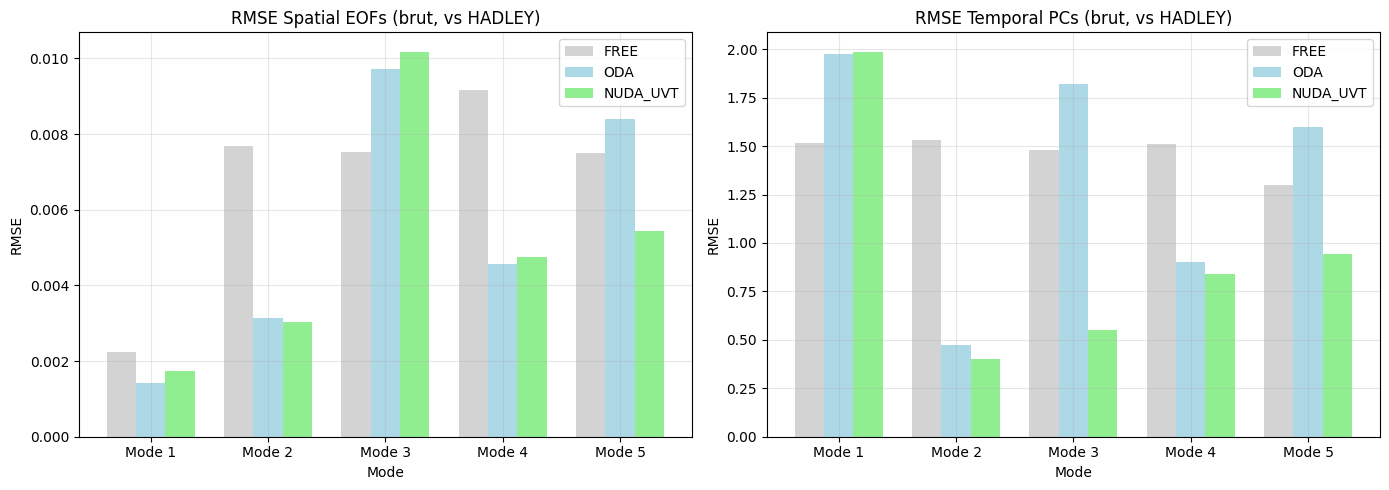

In [187]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# 1️⃣ Fonctions RMSE
# ===============================

def rmse_eof(eof_x, eof_ref):
    """
    RMSE spatial EOF après interpolation sur la grille HADLEY
    - PAS d’orientation
    - PAS de normalisation
    """

    # Interpolation sur la grille HADLEY
    eof_x_interp = eof_x.interp(
        lat=eof_ref["lat"],
        lon=eof_ref["lon"],
        method="linear"
    )

    x = eof_x_interp.values.flatten()
    r = eof_ref.values.flatten()

    mask = np.isfinite(x) & np.isfinite(r)
    return np.sqrt(np.mean((x[mask] - r[mask])**2))



def rmse_pc(pc_x, pc_ref):
    """RMSE temporel PC (brut, non standardisé)"""
    mask = np.isfinite(pc_x) & np.isfinite(pc_ref)
    return np.sqrt(np.mean((pc_x[mask] - pc_ref[mask])**2))


# ===============================
# 2️⃣ Paramètres
# ===============================

datasets_keys = ["FREE", "ODA", "NUDA_UVT"]
nmodes = 5
modes = np.arange(1, nmodes + 1)

# ===============================
# 3️⃣ Calcul RMSE
# ===============================

df_rmse_eof = pd.DataFrame(index=modes, columns=datasets_keys)
df_rmse_pc  = pd.DataFrame(index=modes, columns=datasets_keys)

for i in range(nmodes):

    eof_ref = datasets["HADLEY"]["EOFs"][i]
    pc_ref  = datasets["HADLEY"]["PCs"][:, i].values

    for key in datasets_keys:

        eof_x = datasets[key]["EOFs"][i]
        pc_x  = datasets[key]["PCs"][:, i].values

        # RMSE BRUT
        df_rmse_eof.loc[i+1, key] = rmse_eof(eof_x, eof_ref)
        df_rmse_pc.loc[i+1, key]  = rmse_pc(pc_x, pc_ref)

df_rmse_eof = df_rmse_eof.astype(float)
df_rmse_pc  = df_rmse_pc.astype(float)

print("RMSE EOFs (brut)")
display(df_rmse_eof)

print("RMSE PCs (brut)")
display(df_rmse_pc)


# ===============================
# 4️⃣ PLOTS
# ===============================

width = 0.25
colors = ["lightgray", "lightblue", "lightgreen"]

fig, axs = plt.subplots(1, 2, figsize=(14,5), sharex=True)

# --- RMSE EOFs ---
ax = axs[0]
for i, key in enumerate(datasets_keys):
    ax.bar(
        modes + (i-1)*width,
        df_rmse_eof[key],
        width,
        label=key,
        color=colors[i]
    )

ax.set_title("RMSE Spatial EOFs (brut, vs HADLEY)")
ax.set_ylabel("RMSE")
ax.set_xlabel("Mode")
ax.legend()
ax.grid(alpha=0.3)

# --- RMSE PCs ---
ax = axs[1]
for i, key in enumerate(datasets_keys):
    ax.bar(
        modes + (i-1)*width,
        df_rmse_pc[key],
        width,
        label=key,
        color=colors[i]
    )

ax.set_title("RMSE Temporal PCs (brut, vs HADLEY)")
ax.set_ylabel("RMSE")
ax.set_xlabel("Mode")
ax.legend()
ax.grid(alpha=0.3)

plt.xticks(modes, [f"Mode {i}" for i in modes])
plt.tight_layout()
plt.show()


In [ ]:
print("=== RMSE EOFs ===")
print(df_rmse_eof.round(4))

=== RMSE EOFs ===
     FREE     ODA  NUDA_UVT
1  0.0022  0.0110    0.0109
2  0.0077  0.0104    0.0104
3  0.0075  0.0097    0.0102
4  0.0092  0.0046    0.0048
5  0.0075  0.0084    0.0054


In [188]:
print("=== RMSE PCs ===")
print(df_rmse_pc.round(4))


=== RMSE PCs ===
     FREE     ODA  NUDA_UVT
1  1.5164  1.9778    1.9878
2  1.5332  0.4722    0.4009
3  1.4819  1.8230    0.5515
4  1.5093  0.9007    0.8416
5  1.3013  1.5997    0.9415
